In [1]:
import requests
from bs4 import BeautifulSoup as bs
import json

In [ ]:
# requests: 브라우저(요청 도구, 응답 처리 도구)
requests.get() # get 요청
requests.post() # post 요청

In [10]:
response = requests.get("https://jsonplaceholder.typicode.com/users")

## 역직렬화

In [12]:
# .loads(): json -> python 객체
datas = json.loads(response.text)

## 직렬화

In [13]:
# dumps: python 객체 -> json
datas = json.dumps(datas)

In [15]:
url = "https://www.melon.com/chart/index.htm"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"}

response = requests.get(url, headers=headers)

In [19]:
# BeautifulSoup: html parser
soup = bs(response.text, "html.parser")

In [21]:
# 선택자 선택이 가능
soup.find("span", class_="hour")

<span class="hour">16:00</span>

In [22]:
soup.select("span.hour")

[<span class="hour">16:00</span>]

In [24]:
# .text: 태그의 내용
soup.select_one("span.hour").text

'16:00'

In [26]:
song_list = soup.select("tbody tr")

In [40]:
song_datas = []

for i, tag in enumerate(song_list):
    song_td = tag.select("td")[5]
    
    song_title = song_td.select("a")[0].text
    singer = song_td.select("a")[1].text

    song_datas.append((str((i + 1)) + "위", song_title, singer))

In [43]:
song_datas

[('1위', '소문의 낙원', 'AKMU\xa0(악뮤)'),
 ('2위', '기쁨, 슬픔, 아름다운 마음', 'AKMU\xa0(악뮤)'),
 ('3위', 'REDRED', 'CORTIS\xa0(코르티스)'),
 ('4위', 'RUDE!', 'Hearts2Hearts\xa0(하츠투하츠)'),
 ('5위', 'It′s Me', '아일릿(ILLIT)'),
 ('6위', 'BANG BANG', 'IVE\xa0(아이브)'),
 ('7위', '사랑하게 될 거야', '한로로'),
 ('8위', '캐치 캐치', 'YENA\xa0(최예나)'),
 ('9위', '404 (New Era)', 'KiiiKiii\xa0(키키)'),
 ('10위', 'Drowning', 'WOODZ'),
 ('11위', '0+0', '한로로'),
 ('12위', 'SWIM', '방탄소년단'),
 ('13위', 'Good Goodbye', '화사\xa0(HWASA)'),
 ('14위', '타임캡슐', '다비치'),
 ('15위', 'Popcorn', '도경수(D.O.)'),
 ('16위', '너에게 닿기를', '10CM'),
 ('17위', '멸종위기사랑', '이찬혁'),
 ('18위', 'Body to Body', '방탄소년단'),
 ('19위', '어떻게 이별까지 사랑하겠어, 널 사랑하는 거지', 'AKMU\xa0(악뮤)'),
 ('20위', '그대 작은 나의 세상이 되어', '카더가든'),
 ('21위', '어제보다 슬픈 오늘', '우디\xa0(Woody)'),
 ('22위', 'Blue Valentine', 'NMIXX'),
 ('23위', '너의 모든 순간', '성시경'),
 ('24위', '뛰어(JUMP)', 'BLACKPINK'),
 ('25위', 'Golden', 'HUNTR/X'),
 ('26위', '모르시나요(PROD.로코베리)', '조째즈'),
 ('27위', '2.0', '방탄소년단'),
 ('28위', 'toxic till the end', '로제\xa0(ROSÉ)'),
 ('

In [2]:
import csv
import os

In [46]:
# r"": 경로 이슈 해결
folder_path = r"C:\Users\windows\Desktop\back_0900_nmg\python\resource\csv"
file_name = "melon.csv"

file_path = os.path.join(folder_path, file_name)
print(file_path)

C:\Users\windows\Desktop\back_0900_nmg\python\resource\csv\melon.csv


In [89]:
with open(file_path, "w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)

    writer.writerow(["순위", "곡제목", "가수"])
    writer.writerows(song_datas)

In [3]:
import requests
from bs4 import BeautifulSoup as bs

In [104]:
# 주식 크롤링
url = "https://finance.naver.com/sise/lastsearch2.naver"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36"}

response = requests.get(url, headers=headers)

In [105]:
response.text

'<!--  global include -->\n\n\t\n\t\n<html lang=\'ko\'>\n<head>\n\n\n\t\n\t\n\t\t\n\t\t\t\n\t\t\t\t<title>Npay 증권</title>\n\t\t\t\n\t\t\t\n\t\t\n\t\n\n\n\n\n<meta http-equiv="Content-Type" content="text/html; charset=utf-8" />\n\n<meta http-equiv="Content-Script-Type" content="text/javascript">\n<meta http-equiv="Content-Style-Type" content="text/css">\n<meta name="apple-mobile-web-app-title" content="Npay 증권" />\n\n\n\n\n\n\t\n\t\t<meta property="og:title" content="Npay 증권"/>\n\t\t<meta property="og:image" content="https://ssl.pstatic.net/static/m/stock/im/2016/08/og_stock-200.png"/>\n\t\t<meta property="og:url" content="https://finance.naver.com"/>\n\t\t<meta property="og:description" content="국내 해외 증시 지수, 시장지표, 뉴스, 증권사 리서치 등 제공"/>\n    \n    \n\n<meta property="og:type" content="article"/>\n<meta property="og:article:thumbnailUrl" content=""/>\n<meta property="og:article:author" content="Npay 증권"/>\n<meta property="og:article:author:url" content="http://FINANCE.NAVER.COM"/>\n\n\n\n\

In [107]:
response.status_code

200

In [108]:
response.encoding = "euc-kr"

In [110]:
soup = bs(response.text, "html.parser")

In [111]:
len(soup.select("a"))

102

In [113]:
soup.select("a")[:5]

[<a href="#menu" tabindex="1"><span>메인 메뉴로 바로가기</span></a>,
 <a href="#start" tabindex="2"><span>본문으로 바로가기</span></a>,
 <a class="logo_link" href="https://www.naver.com/" onclick="clickcr(this, 'STA.naver', '', '', event);">
 <svg fill="none" height="22" viewbox="0 0 22 22" width="22" xmlns="http://www.w3.org/2000/svg">
 <path d="M22 11C22 13.1756 21.3549 15.3023 20.1462 17.1113C18.9375 18.9202 17.2195 20.3301 15.2095 21.1627C13.1995 21.9952 10.9878 22.2131 8.85401 21.7886C6.72022 21.3642 4.76021 20.3166 3.22183 18.7782C1.68345 17.2398 0.635805 15.2798 0.211368 13.146C-0.213069 11.0122 0.00476298 8.80047 0.837327 6.79048C1.66989 4.78049 3.07979 3.06253 4.88873 1.85383C6.69768 0.645137 8.82441 0 11 0C13.9174 0 16.7153 1.15893 18.7782 3.22183C20.8411 5.28473 22 8.08262 22 11ZM12.8398 5.83V11.3602L8.98976 5.83H5.83V16.1838H9.1575V10.637L13.0075 16.17H16.1783V5.83H12.8398Z" fill="#000"></path>
 </svg>
 <span class="blind">네이버</span>
 </a>,
 <a class="logo_link" href="https://new-m.pay.nave

In [115]:
len(soup.select("table"))

2

In [118]:
len(soup.select("table.type_5"))

1

In [119]:
len(stock_list)

50

In [117]:
stock_list = soup.select("table.type_5 tr")

In [120]:
stock_datas = []

for tag in stock_list:
    a_tag = tag.select_one("td a")
    if a_tag:
        stock_title = a_tag.text.strip()
        if stock_title:
            stock_datas.append((f"{len(stock_datas) + 1}위", stock_title))

In [121]:
stock_datas

[('1위', '삼성전자'),
 ('2위', 'SK하이닉스'),
 ('3위', '현대차'),
 ('4위', '대한광통신'),
 ('5위', '두산에너빌리티'),
 ('6위', '코스모로보틱스'),
 ('7위', '삼성중공업'),
 ('8위', 'SK스퀘어'),
 ('9위', '삼성SDI'),
 ('10위', '미래에셋증권'),
 ('11위', '삼성증권'),
 ('12위', '한미반도체'),
 ('13위', '셀트리온'),
 ('14위', '삼성전자우'),
 ('15위', 'LS ELECTRIC'),
 ('16위', 'POSCO홀딩스'),
 ('17위', '에코프로'),
 ('18위', '레인보우로보틱스'),
 ('19위', '삼성전기'),
 ('20위', 'NAVER'),
 ('21위', '대한전선'),
 ('22위', '기아'),
 ('23위', '한화오션'),
 ('24위', '현대무벡스'),
 ('25위', '대우건설'),
 ('26위', '로보티즈'),
 ('27위', '에코프로비엠'),
 ('28위', 'LG전자'),
 ('29위', '한온시스템'),
 ('30위', 'SKC')]

## 셀레니움(Selenium)
- 셀레니움(Selenium)은 웹 브라우저를 자동으로 제어할 수 있는 오픈소스 툴로
웹 애플리케이션을 테스트하거나 크롤링하기 위해 사용되는 브라우저 자동화 도구이다.
Chrome, Firefox, Edge 등 여러가지 브라우저에서 작업이 가능하며,
동작하지 않는 브라우저도 존재하며, 로그인, 폼 제출, 버튼 클릭 등 작업을
자동화 할 수 있다

In [83]:
!pip install selenium

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.6 MB 23.0 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 20.6 MB/s  0:00:00

   ---------------------------------------- 0/7 [sortedcontainers]
   ----- ---------------------------------- 1/7 [wsproto]
   ----- ---------------------------------- 1/7 [wsproto]
   ----------- ---------------------------- 2/7 [pysocks]
   ----------------- ---------------------- 3/7 [outcome]
   ---------------------- ----------------- 4/7 [trio]
   ---------------------- ----------------- 4/7 [trio]
   ---------------------- ----------------- 4/7 [trio]
   ---------------------- ----------------- 4/7 [trio]
   ---------------------- ----------------- 4/7 [trio]
   ---------------------- ----------------- 4/7 [trio]
   ---------------------- ----------------- 4/7 [trio]
   ---------------

In [4]:
import selenium
from selenium.webdriver import Chrome # 크롬 자동화 도구
from selenium.webdriver.common.keys import Keys # 자동화 도구 키 제어
from selenium.webdriver.common.by import By
import time

In [99]:
driver = Chrome()

url="https://www.google.com/"
driver.get(url)

In [101]:
# driver.find_element("속성명", "속성값")
# search = driver.find_element(By.ID, "gLFyf")
# search = driver.find_element(By.NAME, "gLFyf")

search = driver.find_element(By.CLASS_NAME, "gLFyf")
search.send_keys("고양이")

In [102]:
# 엔터
search.send_keys(Keys.RETURN)

In [123]:
url = "https://comic.naver.com/webtoon/detail?titleId=733074&no=273&week=mon"

In [126]:
time.sleep(2)
print("2초 뒤에 실행")

2초 뒤에 실행


In [127]:
driver.get(url)
time.sleep(2)

soup = bs(driver.page_source)

<html lang="ko"><head>
<meta content="text/html; charset=utf-8" http-equiv="Content-type"/>
<meta content="IE=edge, chrome=1" http-equiv="X-UA-Compatible"/>
<meta content="article" property="og:type"/>
<meta content="네이버 웹툰" property="og:article:author"/>
<meta content="https://comic.naver.com" property="og:article:author:url"/>
<meta content="백수세끼 - 273화 오징어덮밥" property="og:title"/>
<meta content="https://shared-comic.pstatic.net/thumb/webtoon/733074/273/thumbnail_600x315_efb5f0aa-9d58-43e9-bcdb-ffd12f1f3f7a.jpg" property="og:image"/>
<title>백수세끼 - 273화 오징어덮밥 : 네이버 웹툰</title>
<link href="https://shared-comic.pstatic.net/favicon/favicon_96x96.ico" rel="icon" type="image/x-icon"/>
<link href="https://ssl.pstatic.net/static/wcc/kw/prod-1.0/index.css?v=202605111720" rel="stylesheet" type="text/css"/>
<link href="/39293056ef7d8bcbcde7.css" rel="stylesheet"/>
<script>
        if (/MSIE \d|Trident.*rv:/.test(navigator.userAgent)) {
            window.location = 'microsoft-edge:' + window.loc
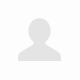
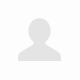
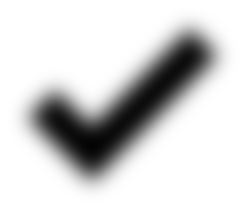

In [128]:
print(soup)

In [133]:
all_reply_button = driver.find_elements(By.CLASS_NAME, "_root_14no7_1")[1]

In [134]:
all_reply_button.click()

In [139]:
more_button = driver.find_element(By.CLASS_NAME, "eE2Vs")

In [140]:
for i in range(5):
    time.sleep(5)
    more_button.click()

In [143]:
def get_reply():
    try:
        driver = Chrome()
    
        url = "https://comic.naver.com/webtoon/detail?titleId=733074&no=273&week=mon"
        driver.get(url)
    
        time.sleep(3)
        all_reply_button = driver.find_elements(By.CLASS_NAME, "_root_14no7_1")[1]
        all_reply_button.click()
    
        time.sleep(3)
        more_button = driver.find_element(By.CLASS_NAME, "eE2Vs")
        for i in range(5):
            time.sleep(5)
            more_button.click()
            
        soup = bs(driver.page_source)
        return soup    
        
    
    except StaleElementReferenceException:
        soup = bs(driver.page_source)
        return soup

In [10]:
soup = get_reply()

NameError: name 'get_reply' is not defined

In [11]:
url = "https://velog.io/"

## Velog

In [5]:
driver = Chrome()
driver.get(url)

In [13]:
# 페이지 소스
# driver.page_source

In [16]:
# 스크롤 다운
driver.execute_script("window.scrollTo(0, document.body.scrollHeight)")

In [18]:
for i in range(3):
    time.sleep(3)
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight)")

In [26]:
soup = bs(driver.page_source)

In [30]:
def parse_list(class_name):
    return list(map(lambda tag: tag.text, soup.select(class_name)))

In [32]:
titles = parse_list(".PostCard_h4__6dTLA")
contents = parse_list(".PostCard_clamp___2g_C")

posts = zip(titles, contents)

In [33]:
list(posts)

[('그만할게요', '1300일동안 하루도 빠짐없이 백준을 풀어왔던 후기입니다.'),
 ('바이브코딩 직무 면접 회고',
  '면접을 봤다.\n순수 AI Native 빌더 면접이었고, 지원만해도 최소 2만 원, 합격하면 10만 원 상품권을 주는 초호화(?) 공고였다.\n덜컥 1차에 합격했고 면접을 준비했다.'),
 ('당근 에서의 9개월을 마무리 하며',
  '2025년 8월 4일에 입사하여 2026년 4월 30일 까지 9개월을 근무하며 팀도 옮기고 많은 것들을 배우고 경험해서 기억이 휘발되기 전에 이렇게 글로 남겨보려 한다. '),
 ('EP4. JSP의 마법사 이건우에게 정처기 합격비결을 묻다', '이건우 그에 대해 알아보자'),
 ('드롭다운에서 Korea를 찾아주는 크롬 익스텐션',
  '외국 사이트에서 회원가입할 때 국가를 선택하는 드롭다운에서 한국 표시를 찾기 어려운 경험이 있어서 만들어 봤어요.South Korea인 경우도 있고, Korea South, 또는 Republic of Korea 등 다양한 선택지가 있어서 한 번에 찾기 어렵다는 문제를 ...'),
 ('브라우저에서 C++를 채점한다. — NEXT JUDGE 개발기 (오픈 온라인 저지 — 안녕, 백준)',
  '크래프톤 정글에서 알고리즘을 공부하면서 백준 온라인 저지를 자주 사용했어요. 최근 서비스가 종료되면서, 문제와 테스트케이스를 보존하려고 데이터를 아카이빙해 공개 저장소에 정리했습니다.이 과정에서 커뮤니티 기반 오픈 알고리즘 저지 플랫폼까지 아이디어를 확장하게 됐어요. ...'),
 ('토스페이먼츠 서버 개발자 합격 회고', '토스페이먼츠 서버 개발자 합격 회고'),
 ('[당근/회고] 인턴 출근 3주차 회고', '당근에서의 3주차 회고'),
 ('EP6.벨로그 어그로 1황 김태현에게 취업현황을 묻다', '김태현 그에 대해 알아보자'),
 ('EP5. 브라키오사우르스 김현우에게 티라노사우르스와 맞짱까면 누가 이길지를 묻다', '김현우 그에 대해 알아보자'),
 ('보상 트랜잭션, 사

In [38]:
iamges = list(map(lambda image: image.get("src"), soup.select(".PostCard_block__FTMsy img")[::2]))
thumbs = list(map(lambda image: image.get("src"), soup.select(".PostCard_block__FTMsy img")[1::2]))

iamges
thumbs

['https://velog.velcdn.com/images/yoochanhong/profile/e57eab65-e72f-47aa-8284-a38d68ec190f/social_profile.jpeg',
 'https://velog.velcdn.com/images/dbwls/profile/5014f6b5-0c74-4f1a-8f38-4d0a4af0aad9/image.jpg',
 'https://velog.velcdn.com/images/yoose1002/profile/1445ccba-4408-4b3b-bfea-aba59259e863/image.jpeg',
 'https://velog.velcdn.com/images/x0gus/profile/458760d7-7abc-4962-9042-183b3dc55d79/image.png',
 'https://velog.velcdn.com/images/hello1234/profile/8a71f96d-2b82-410e-b9cc-d6094c0cca6c/image.png',
 'https://velog.velcdn.com/images/suinkim/profile/39699224-b9bf-486d-920a-52e6cbd087c0/image.jpg',
 'https://velcdn.com/images/user-thumbnail.png',
 'https://velog.velcdn.com/images/dev-dino22/profile/cac4c230-9f08-4c3a-bfbf-c1d07666a8ed/image.JPG',
 'https://velog.velcdn.com/images/x0gus/profile/458760d7-7abc-4962-9042-183b3dc55d79/image.png',
 'https://velog.velcdn.com/images/x0gus/profile/458760d7-7abc-4962-9042-183b3dc55d79/image.png',
 'https://velog.velcdn.com/images/sh__y_/profi